In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set()

# EDA — Dataset Hitters (salarios de béisbol)
**Aprendizaje de Máquina - CEIA - FIUBA**

*Notebook auxiliar (no forma parte del flujo de clase).*

El dataset **Hitters** contiene estadísticas de **322 jugadores de béisbol** de las Grandes Ligas de EE.UU. correspondientes a la temporada 1986 y a su carrera, junto con el **salario de 1987**. Los datos provienen de la biblioteca StatLib (Carnegie Mellon); los salarios son de *Sports Illustrated* (20 de abril de 1987) y las estadísticas del *1987 Baseball Encyclopedia Update*. Detalle de cada variable [aquí](https://rdrr.io/cran/ISLR/man/Hitters.html).

El objetivo de modelado es **predecir el salario de 1987** a partir del desempeño del jugador. Este EDA justifica las decisiones de preprocesamiento (transformación del target, variables dummy, escalado) que se usan luego en `3 - SVM (Regresion).ipynb`.

## Variables

| Feature | Descripción |
|---|---|
| `AtBat`, `Hits`, `HmRun`, `Runs`, `RBI`, `Walks` | Veces al bate, hits, home runs, carreras, carreras impulsadas y bases por bolas en **1986** |
| `Years` | Años en las Grandes Ligas |
| `CAtBat`, `CHits`, `CHmRun`, `CRuns`, `CRBI`, `CWalks` | Los mismos totales pero **acumulados en toda la carrera** |
| `League`, `Division`, `NewLeague` | Liga y división (categóricas: A/N, E/W) |
| `PutOuts`, `Assists`, `Errors` | Estadísticas defensivas de 1986 |
| `Salary` | **Salario anual de 1987** (miles de USD) — variable objetivo |

In [2]:
df_hitters = pd.read_csv("datasets/Hitters.csv")

print("Dimensiones:", df_hitters.shape)
df_hitters.head()

Dimensiones: (322, 20)


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [3]:
df_hitters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AtBat      322 non-null    int64  
 1   Hits       322 non-null    int64  
 2   HmRun      322 non-null    int64  
 3   Runs       322 non-null    int64  
 4   RBI        322 non-null    int64  
 5   Walks      322 non-null    int64  
 6   Years      322 non-null    int64  
 7   CAtBat     322 non-null    int64  
 8   CHits      322 non-null    int64  
 9   CHmRun     322 non-null    int64  
 10  CRuns      322 non-null    int64  
 11  CRBI       322 non-null    int64  
 12  CWalks     322 non-null    int64  
 13  League     322 non-null    object 
 14  Division   322 non-null    object 
 15  PutOuts    322 non-null    int64  
 16  Assists    322 non-null    int64  
 17  Errors     322 non-null    int64  
 18  Salary     263 non-null    float64
 19  NewLeague  322 non-null    object 
dtypes: float64

## Valores faltantes

El target `Salary` es la única variable con datos ausentes.

In [4]:
faltantes = df_hitters.isna().sum()
faltantes[faltantes > 0]

Salary    59
dtype: int64

Hay **59 jugadores sin salario registrado** (18% del total). Como es la variable que queremos predecir, no tiene sentido imputarla: esos registros se descartan antes de modelar.

In [5]:
df_hitters = df_hitters.dropna(subset="Salary").copy()
print("Registros con salario:", len(df_hitters))

Registros con salario: 263


## Distribución del target y transformación logarítmica

El salario suele tener una distribución muy asimétrica hacia la derecha (pocos jugadores muy bien pagos). Los modelos lineales y de márgenes funcionan mejor con un target más simétrico, así que evaluamos aplicar `log(Salary)`.

Asimetría (skew) de Salary:      1.589
Asimetría (skew) de log(Salary): -0.182


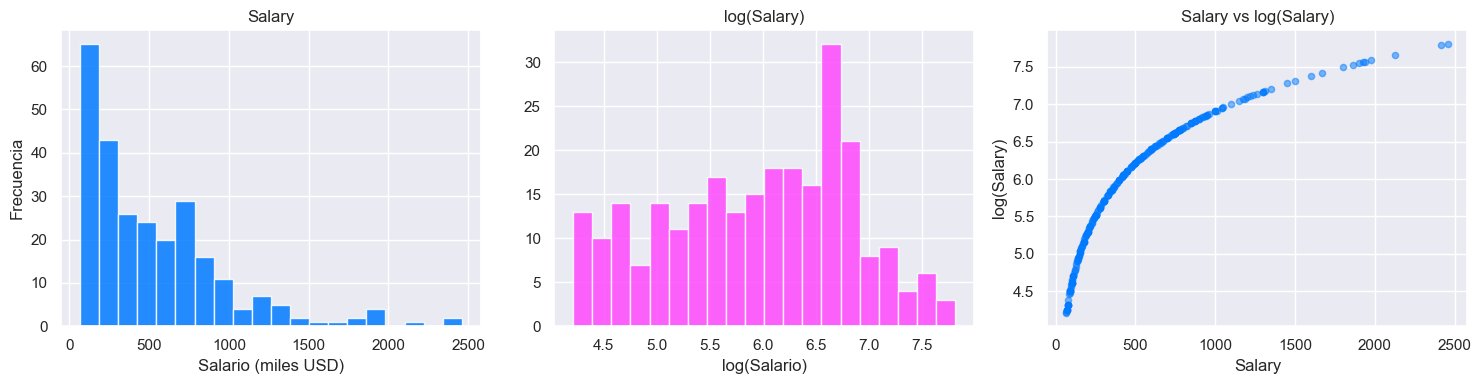

In [6]:
df_hitters["Salary_log"] = np.log(df_hitters["Salary"])

print(f"Asimetría (skew) de Salary:      {df_hitters['Salary'].skew():.3f}")
print(f"Asimetría (skew) de log(Salary): {df_hitters['Salary_log'].skew():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_hitters["Salary"], bins=20, color="#007aff", alpha=0.85)
axes[0].set_title("Salary")
axes[0].set_xlabel("Salario (miles USD)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(df_hitters["Salary_log"], bins=20, color="#ff48fd", alpha=0.85)
axes[1].set_title("log(Salary)")
axes[1].set_xlabel("log(Salario)")

axes[2].scatter(df_hitters["Salary"], df_hitters["Salary_log"],
                color="#007aff", alpha=0.5, s=20)
axes[2].set_title("Salary vs log(Salary)")
axes[2].set_xlabel("Salary")
axes[2].set_ylabel("log(Salary)")

plt.tight_layout()
plt.show()

La transformación reduce fuertemente la asimetría (de ~1.6 a ~-0.18) y descomprime los salarios bajos, que antes se amontonaban en los primeros bins. **Por eso modelamos `log(Salary)` en lugar de `Salary`.**

---
## Variables categóricas

`League`, `Division` y `NewLeague` son las únicas variables no numéricas. Veamos su distribución y si se asocian con el salario.

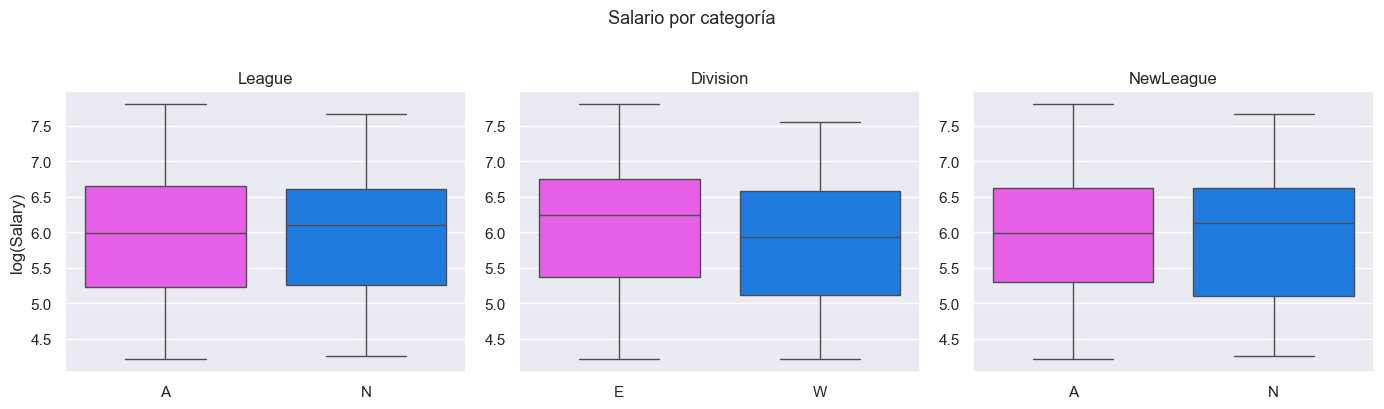

In [7]:
categoricas = ["League", "Division", "NewLeague"]
paleta_cat = ["#007aff", "#ff48fd"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, categoricas):
    orden = sorted(df_hitters[col].unique())
    sns.boxplot(data=df_hitters, x=col, y="Salary_log", order=orden,
                hue=col, legend=False,
                palette=paleta_cat, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("log(Salary)" if ax is axes[0] else "")

plt.suptitle("Salario por categoría", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Las categóricas casi no separan el salario: las medianas son muy parecidas entre grupos. Aportan poca señal, pero las incluimos como variables dummy porque no molestan y pueden capturar interacciones menores.

---
## ¿Qué variables predicen el salario?

Calculamos la correlación de cada feature numérica con `log(Salary)`.

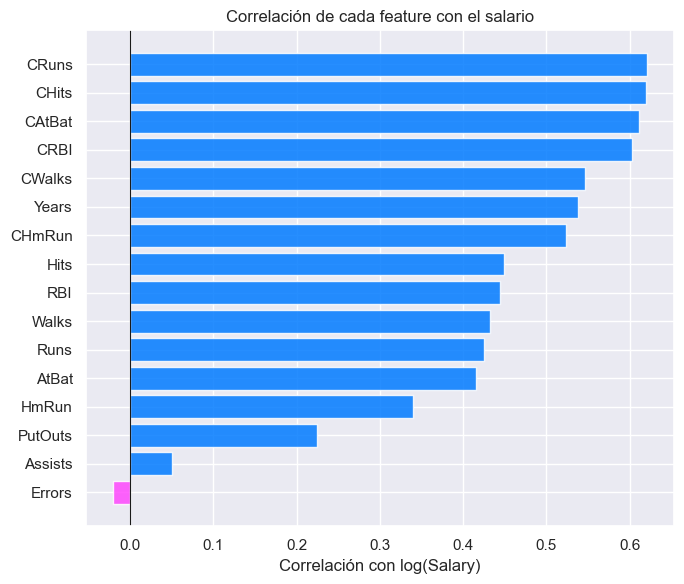

In [8]:
num_cols = df_hitters.select_dtypes(include=[np.number]).drop(
    columns=["Salary", "Salary_log"]).columns
corr_target = (df_hitters[list(num_cols) + ["Salary_log"]].corr()["Salary_log"]
               .drop("Salary_log").sort_values())

fig, ax = plt.subplots(figsize=(7, 6))
colores = ["#007aff" if v > 0 else "#ff48fd" for v in corr_target]
ax.barh(corr_target.index, corr_target.values, color=colores, alpha=0.85)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_xlabel("Correlación con log(Salary)")
ax.set_title("Correlación de cada feature con el salario")
plt.tight_layout()
plt.show()

Los predictores más fuertes son las **estadísticas acumuladas de carrera** (`CRuns`, `CHits`, `CAtBat`, `CRBI`, `CWalks`) y los `Years`: tiene sentido, un jugador con una carrera larga y productiva cobra más. Las estadísticas de la temporada 1986 sola correlacionan algo menos.

---
## Matriz de correlación

Como muchas variables de carrera miden cosas parecidas, esperamos **fuerte multicolinealidad** entre ellas.

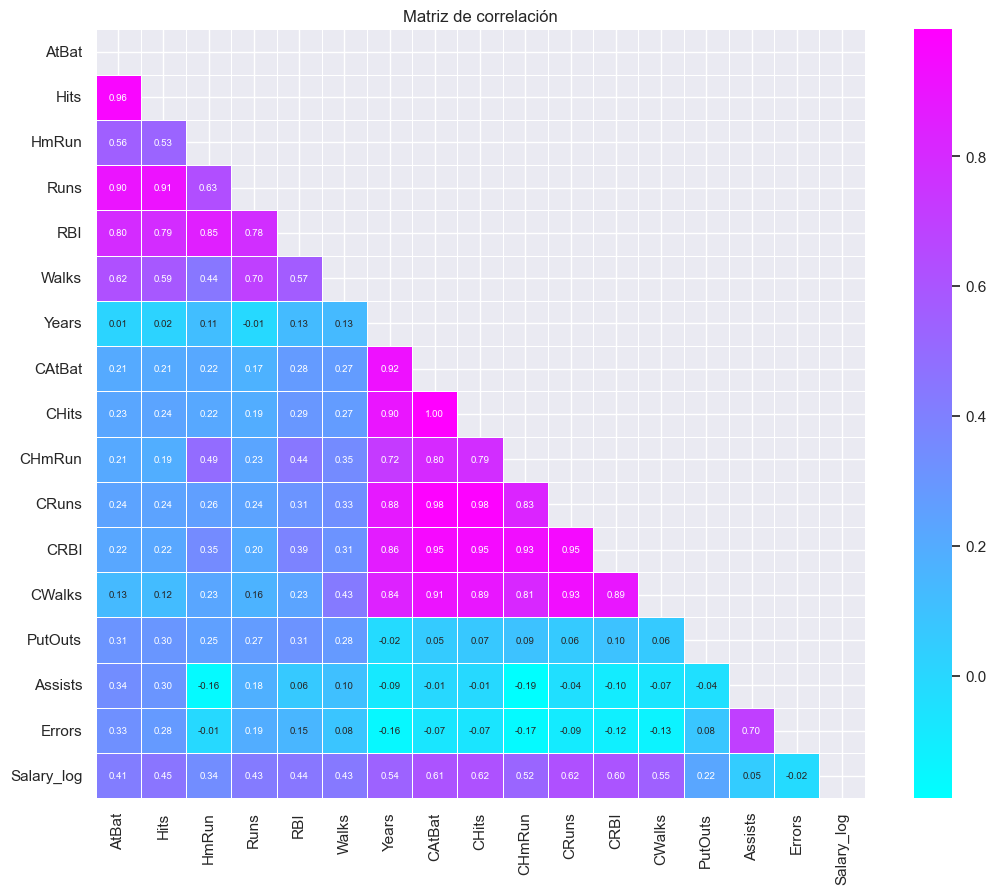

In [9]:
corr = df_hitters[list(num_cols) + ["Salary_log"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="cool",
            cbar=True, ax=ax, square=True, linewidths=0.5,
            annot_kws={"size": 7})
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

Las variables de carrera (`CAtBat`, `CHits`, `CRuns`, `CRBI`, ...) están **altísimamente correlacionadas entre sí** (>0.9). Esto es multicolinealidad severa: justifica usar modelos **regularizados** (Ridge, o el margen de SVR) en lugar de una regresión lineal ordinaria, que se vuelve inestable con features redundantes.

---
## Relación de los mejores predictores con el salario

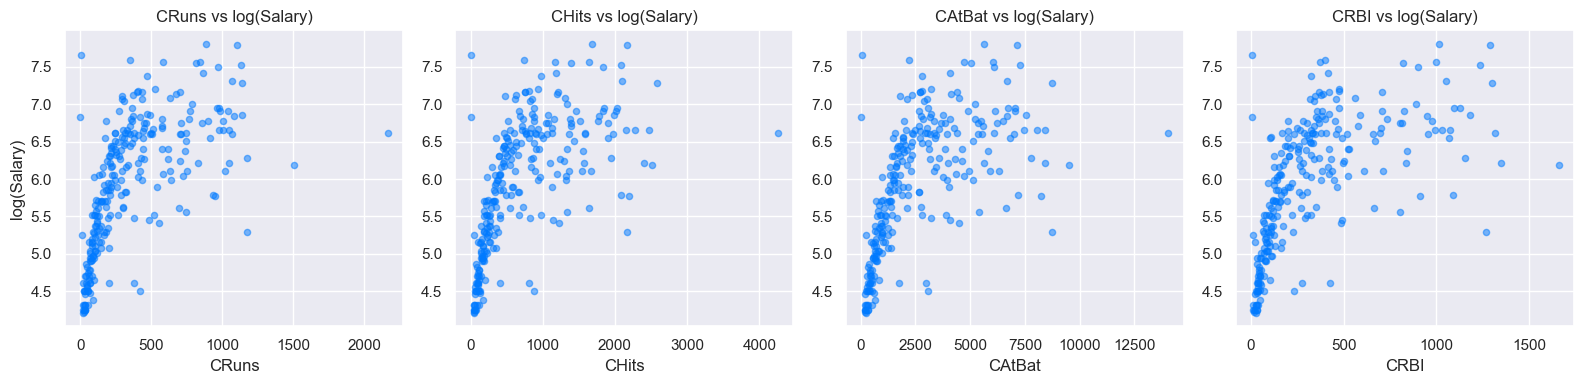

In [10]:
top_feats = corr_target.abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, top_feats):
    ax.scatter(df_hitters[feat], df_hitters["Salary_log"],
               color="#007aff", alpha=0.5, s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel("log(Salary)" if ax is axes[0] else "")
    ax.set_title(f"{feat} vs log(Salary)")

plt.tight_layout()
plt.show()

---
## Observaciones clave

1. El target `Salary` es fuertemente asimétrico; modelamos **`log(Salary)`**, que es casi simétrico.
2. Hay **59 registros sin salario** que se descartan (no se imputa el target).
3. Los mejores predictores son las **estadísticas acumuladas de carrera** y los `Years`.
4. Existe **multicolinealidad severa** entre las variables de carrera → conviene usar modelos regularizados.
5. Las variables categóricas aportan poca señal, pero se incluyen como dummies.

---
## Baseline para comparar

Antes de entrenar modelos complejos definimos un **baseline** simple contra el cual medir cualquier mejora. En lugar de una regresión sobre una sola variable cruda, usamos un baseline por **tabla de referencia según la experiencia**:

> Agrupamos a los jugadores en **tramos de años en las Grandes Ligas** (`Years`) y predecimos, para cada tramo, el **salario promedio** de los jugadores de ese tramo.

Es un baseline sin entrenamiento en el sentido clásico: sólo memoriza un promedio por grupo. La lógica es sólida —el salario crece con la experiencia— y suele ser sorprendentemente competitivo. Elegimos los tramos de modo que cada uno tenga **suficientes jugadores** (~25-40), y los promedios se calculan **sólo sobre el conjunto de entrenamiento** para no filtrar información del test. Como piso de referencia adicional mostramos también el baseline trivial de predecir la media global.

Usamos el mismo split que el resto de las notebooks (`test_size=0.3`, `random_state=42`).

In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

dummies = pd.get_dummies(df_hitters, columns=["League", "Division", "NewLeague"],
                         drop_first=True)
X_cols = ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
          'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'PutOuts', 'Assists',
          'Errors', 'League_N', 'Division_W', 'NewLeague_N']
X = dummies[X_cols]
y = dummies["Salary_log"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
    random_state=42)

# Tramos de experiencia (años). Bordes elegidos para que cada grupo tenga
# suficientes jugadores.
bins = [0, 2, 4, 6, 9, 13, np.inf]
etiquetas = ["1-2", "3-4", "5-6", "7-9", "10-13", "14+"]

tramo_train = pd.cut(X_train["Years"], bins=bins, labels=etiquetas)
tramo_test = pd.cut(X_test["Years"], bins=bins, labels=etiquetas)

# Promedio de log(Salary) por tramo, calculado SOLO en train (evita fuga de datos)
prom_por_tramo = y_train.groupby(tramo_train, observed=False).mean()

tabla = pd.DataFrame({
    "Jugadores (train)": y_train.groupby(tramo_train, observed=False).size(),
    "log(Salary) promedio": prom_por_tramo.round(3),
    "Salary promedio (miles USD)": np.exp(prom_por_tramo).round(1),
})
tabla

,Jugadores (train),log(Salary) promedio,Salary promedio (miles USD)
Years,,,
1-2,27,4.734,113.7
3-4,36,5.346,209.7
5-6,39,6.154,470.6
7-9,31,6.501,666.0
10-13,26,6.539,691.8
14+,25,6.403,603.8


Baseline (media global):
  MAE = 0.7363  R2 = -0.0007
Baseline (promedio por tramo de años):
  MAE = 0.5068  RMSE = 0.7027  R2 = 0.3665


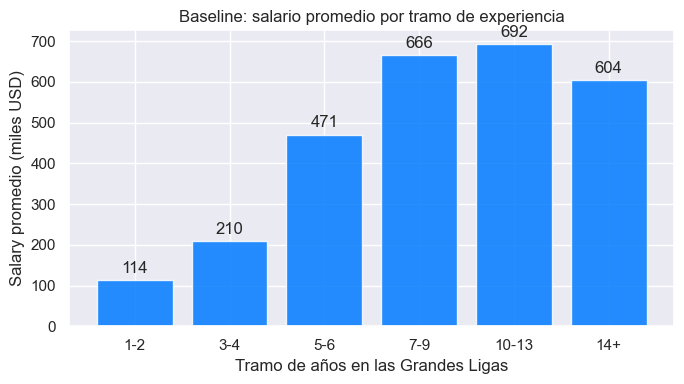

In [12]:
# Predicción: a cada jugador de test le asignamos el promedio de su tramo
y_pred_tramo = tramo_test.map(prom_por_tramo).astype(float).values

# Baseline trivial: la media global (piso de referencia)
y_pred_media = DummyRegressor(strategy="mean").fit(X_train, y_train).predict(X_test)

print("Baseline (media global):")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_media):.4f}  "
      f"R2 = {r2_score(y_test, y_pred_media):.4f}")
print("Baseline (promedio por tramo de años):")
print(f"  MAE = {mean_absolute_error(y_test, y_pred_tramo):.4f}  "
      f"RMSE = {root_mean_squared_error(y_test, y_pred_tramo):.4f}  "
      f"R2 = {r2_score(y_test, y_pred_tramo):.4f}")

# Visualización: salario promedio predicho por cada tramo de experiencia
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prom_por_tramo.index.astype(str),
              np.exp(prom_por_tramo).values, color="#007aff", alpha=0.85)
ax.bar_label(bars, fmt="%.0f", padding=3)
ax.set_xlabel("Tramo de años en las Grandes Ligas")
ax.set_ylabel("Salary promedio (miles USD)")
ax.set_title("Baseline: salario promedio por tramo de experiencia")
plt.tight_layout()
plt.show()

El baseline por **tramo de experiencia** llega a **MAE ≈ 0.51**, bastante mejor que predecir la media global (≈ 0.74) y a la altura de los modelos lineales — con sólo mirar los años de carrera de cada jugador.